# Healthcare Predictive Analytics: Disease Detection

## Project Goal
The goal of this project is to predict the risk of diabetes using machine learning techniques. Predictive analytics in healthcare can assist doctors and healthcare providers in identifying high-risk patients early and taking preventive actions.

This project uses medical data such as glucose levels, BMI, age, and blood pressure to predict whether a patient is likely to develop diabetes.

## Dataset
Dataset: **Pima Indians Diabetes Dataset**

Source:
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

The dataset contains medical diagnostic measurements of patients such as:

- Pregnancies
- Glucose Level
- Blood Pressure
- Skin Thickness
- Insulin Level
- Body Mass Index (BMI)
- Diabetes Pedigree Function
- Age

Target Variable:
- **Outcome** (0 = No Diabetes, 1 = Diabetes)

## Step 1: Import Required Libraries

In this step we import libraries required for:

- Data analysis
- Data visualization
- Data preprocessing
- Machine learning model development
- Model evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

## Step 2: Load the Dataset

The dataset is uploaded manually to Google Colab using the **Files → Upload** option.

After uploading the dataset CSV file, we load it using the Pandas library.

In [2]:
df = pd.read_csv("/content/diabetesCSV.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Dataset Overview

We explore the dataset to understand:

- Number of rows and columns
- Data types
- Statistical summary of features

In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 4: Handling Missing Values

Some medical attributes may contain missing or invalid values (often represented as zero). These values must be handled before training machine learning models.

In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Step 5: Data Cleaning

Certain columns should not contain zero values such as:

- Glucose
- BloodPressure
- BMI
- Insulin
- SkinThickness

We replace zero values with the **median of the column** to maintain realistic medical records.

In [7]:
columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in columns:
    df[col] = df[col].replace(0, df[col].median())

## Step 6: Exploratory Data Analysis (EDA)

EDA helps us understand patterns in the dataset.

We analyze:

- Diabetes distribution
- Age distribution
- Correlation between medical variables

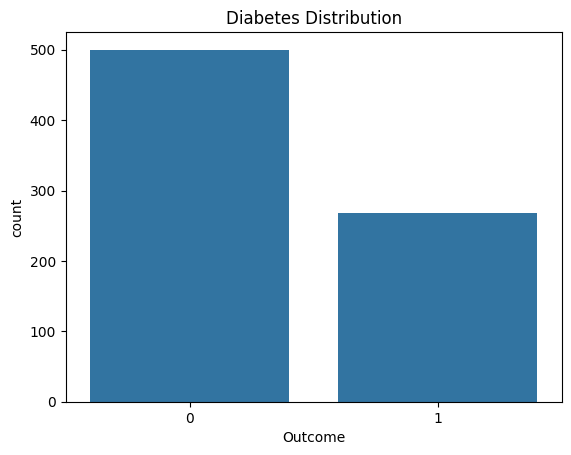

In [8]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

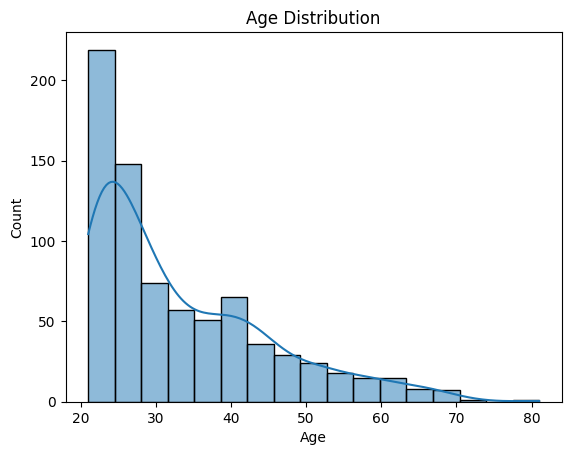

In [9]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

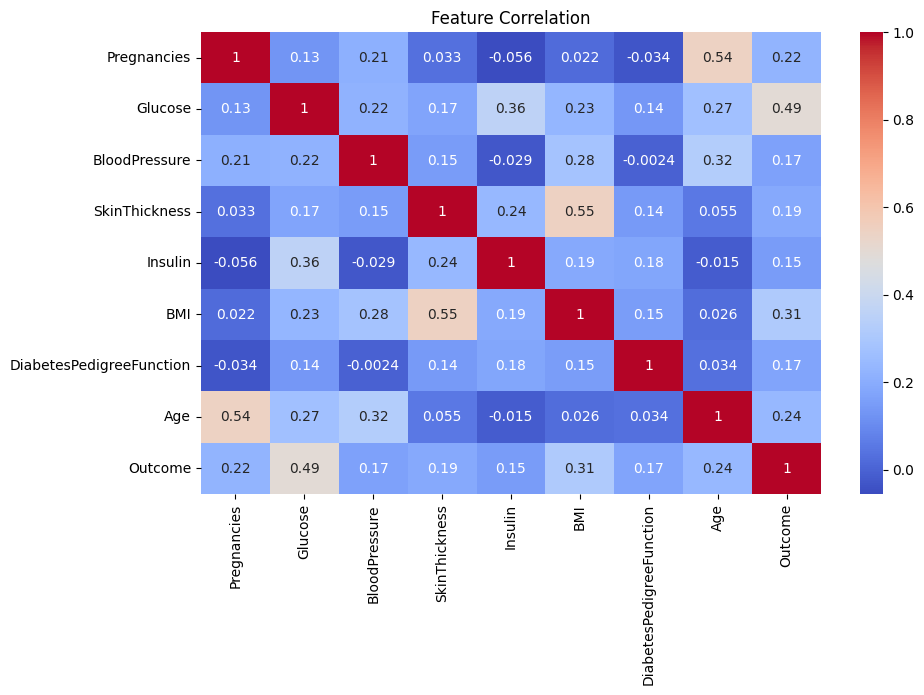

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## Step 7: Feature Selection

We separate the dataset into:

- Features (X)
- Target Variable (y)

Target Variable:
Outcome

In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Step 8: Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

This allows the model to learn patterns and then evaluate its performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Data Normalization

Medical measurements have different ranges (e.g., glucose vs age).  
Normalization ensures consistency and improves model performance.

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 10: Logistic Regression Model

Logistic Regression is a common classification algorithm used in medical prediction tasks.

In [14]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

## Step 11: Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy.

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## Step 12: Model Evaluation

We evaluate the model using:

- Accuracy
- Classification Report
- Confusion Matrix
- ROC-AUC Score

In [16]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7662337662337663
Random Forest Accuracy: 0.7662337662337663


In [17]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



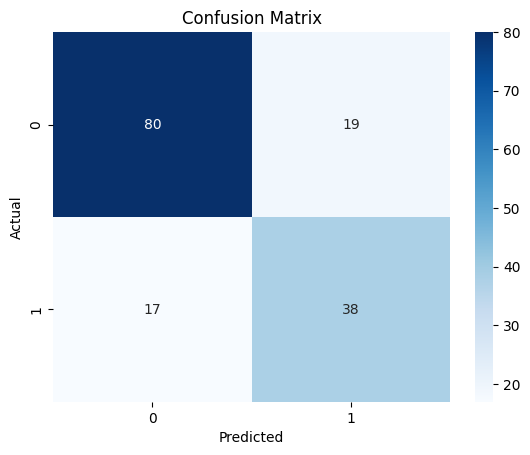

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

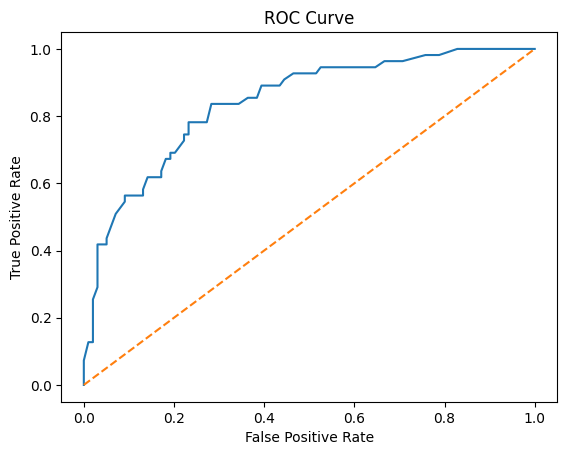

ROC-AUC Score: 0.840495867768595


In [19]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, rf_probs))

## Step 13: Feature Importance

Feature importance helps us understand which medical attributes contribute most to diabetes prediction.

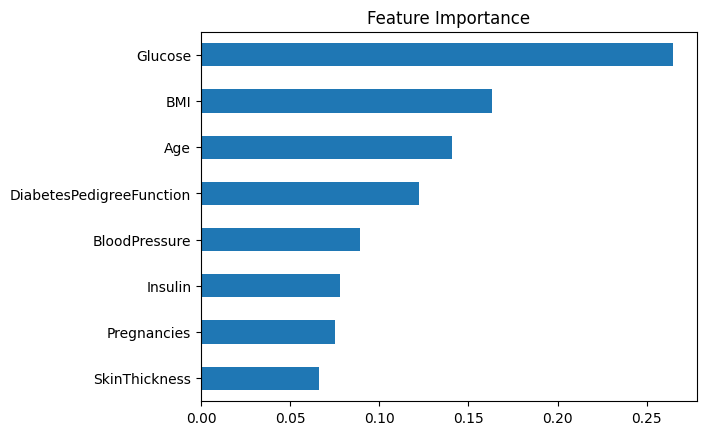

In [20]:
importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()

## Ethical Considerations in Healthcare Data

When working with healthcare data, it is important to ensure:

1. **Patient Privacy**
   Personal identifiers must be removed from datasets to protect patient confidentiality.

2. **Responsible Data Usage**
   Predictive models should support healthcare professionals rather than replace medical decision-making.

3. **Bias Awareness**
   Models should be evaluated carefully to avoid bias that could lead to unfair healthcare outcomes.

4. **Secure Data Handling**
   Healthcare datasets should be stored securely to prevent unauthorized access.

## Conclusion

In this project, we built a **Healthcare Predictive Analytics system** to detect diabetes risk using machine learning.

Key steps included:

- Data preprocessing and normalization
- Exploratory Data Analysis
- Training classification models
- Evaluating models using multiple metrics
- Analyzing feature importance

Such predictive systems can help healthcare providers identify high-risk patients early and improve preventive healthcare strategies.